# Content-Based Movie Recommender System
## Mini-project 1: ISA Development

This notebook performs exploratory data analysis (EDA) and preprocessing on the TMDB movie dataset to build a content-based movie recommender system. We analyze movie metadata including genres, cast, crew, keywords, and plot overviews to understand the data before building our recommendation engine.

In [1]:
import ast
import sys
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.make_dataset import make_dataset
from src.features.build_features import build_features
from src.models.predict_model import ContentBasedRecommender

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
TMDB_IMAGE_BASE_URL = 'https://image.tmdb.org/t/p/w500'

def parse_tmdb_json_array(value):
    """Parse TMDB columns containing Python literal syntax (single-quoted dicts)."""
    if isinstance(value, list):
        return value
    if not isinstance(value, str):
        return []
    value = value.strip()
    if not value or value.lower() == 'nan':
        return []
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return parsed if isinstance(parsed, list) else []

def extract_names(items, key='name', limit=None):
    if not isinstance(items, list):
        return []
    names = [item.get(key) for item in items if isinstance(item, dict) and item.get(key)]
    return names[:limit] if limit is not None else names

def extract_director_name(crew_items):
    if not isinstance(crew_items, list):
        return np.nan
    for item in crew_items:
        if isinstance(item, dict) and item.get('job') == 'Director' and item.get('name'):
            return item['name']
    return np.nan

def build_poster_url(poster_path):
    if pd.isna(poster_path):
        return ''
    poster_path = str(poster_path).strip()
    if not poster_path or poster_path.lower() == 'nan':
        return ''
    return f'{TMDB_IMAGE_BASE_URL}{poster_path}'

## 1. Data Loading

In [3]:
metadata = pd.read_csv('../data/raw/movies_metadata.csv', low_memory=False)
credits = pd.read_csv('../data/raw/credits.csv')
keywords = pd.read_csv('../data/raw/keywords.csv')
links_small = pd.read_csv('../data/raw/links_small.csv')
ratings = pd.read_csv('../data/raw/ratings_small.csv')

## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview

In [4]:
print(f"Movies Metadata: {metadata.shape}")
print(f"Credits: {credits.shape}")
print(f"Keywords: {keywords.shape}")
print(f"Links Small: {links_small.shape}")
print(f"Ratings Small: {ratings.shape}")
print("\n--- Movies Metadata Sample ---")
metadata.head(3)

Movies Metadata: (45466, 24)
Credits: (45476, 3)
Keywords: (46419, 2)
Links Small: (9125, 3)
Ratings Small: (100004, 4)

--- Movies Metadata Sample ---


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [5]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  str    
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [6]:
metadata.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


### 2.2 Missing Values Analysis

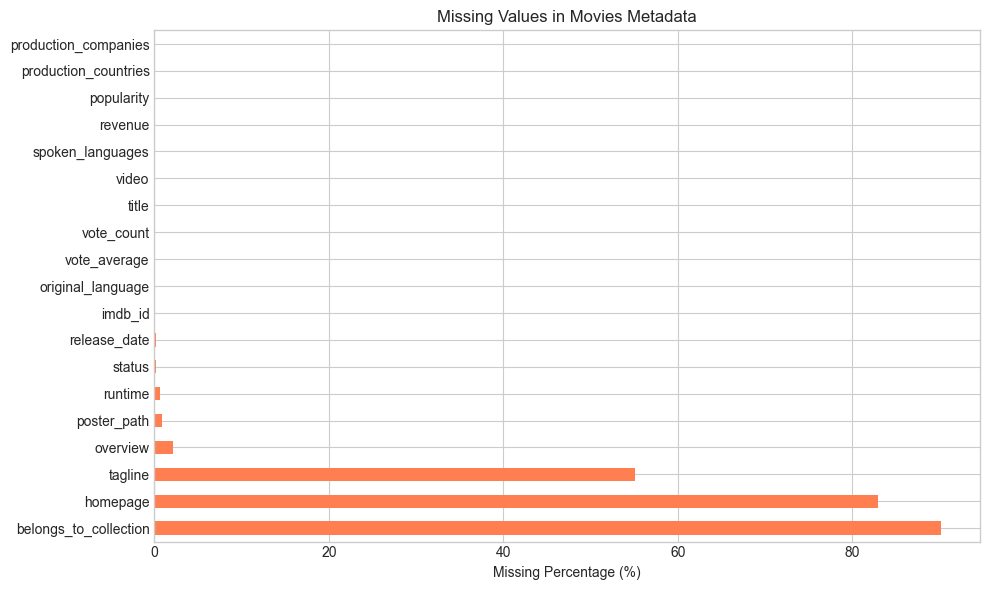


Total rows: 45466

Columns with missing values:
belongs_to_collection    90.115691
homepage                 82.883913
tagline                  55.104914
overview                  2.098271
poster_path               0.848986
runtime                   0.578454
status                    0.191352
release_date              0.191352
imdb_id                   0.037391
original_language         0.024194
vote_average              0.013197
vote_count                0.013197
title                     0.013197
video                     0.013197
spoken_languages          0.013197
revenue                   0.013197
popularity                0.010997
production_countries      0.006598
production_companies      0.006598


In [7]:
missing = metadata.isnull().sum()
missing_pct = (missing / len(metadata) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values in Movies Metadata')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal rows: {len(metadata)}")
print(f"\nColumns with missing values:\n{missing_pct.to_string()}")

### 2.3 Rating Distribution

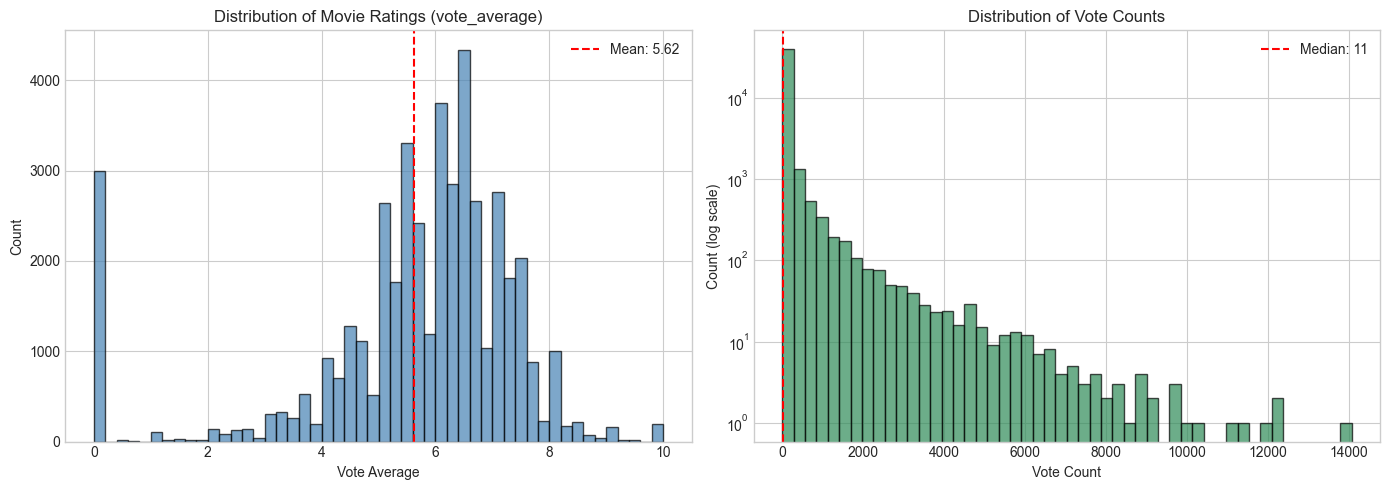

Mean rating: 5.62
Median vote count: 10
Movies with 0 votes: 2899


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(metadata['vote_average'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Vote Average')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Movie Ratings (vote_average)')
axes[0].axvline(metadata['vote_average'].mean(), color='red', linestyle='--', label=f"Mean: {metadata['vote_average'].mean():.2f}")
axes[0].legend()

vote_counts = metadata['vote_count'].dropna()
vote_counts = vote_counts[vote_counts > 0]
axes[1].hist(vote_counts, bins=50, color='seagreen', edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Vote Count')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Vote Counts')
axes[1].axvline(vote_counts.median(), color='red', linestyle='--', label=f"Median: {vote_counts.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean rating: {metadata['vote_average'].mean():.2f}")
print(f"Median vote count: {metadata['vote_count'].median():.0f}")
print(f"Movies with 0 votes: {(metadata['vote_count'] == 0).sum()}")

### 2.4 Genre Analysis

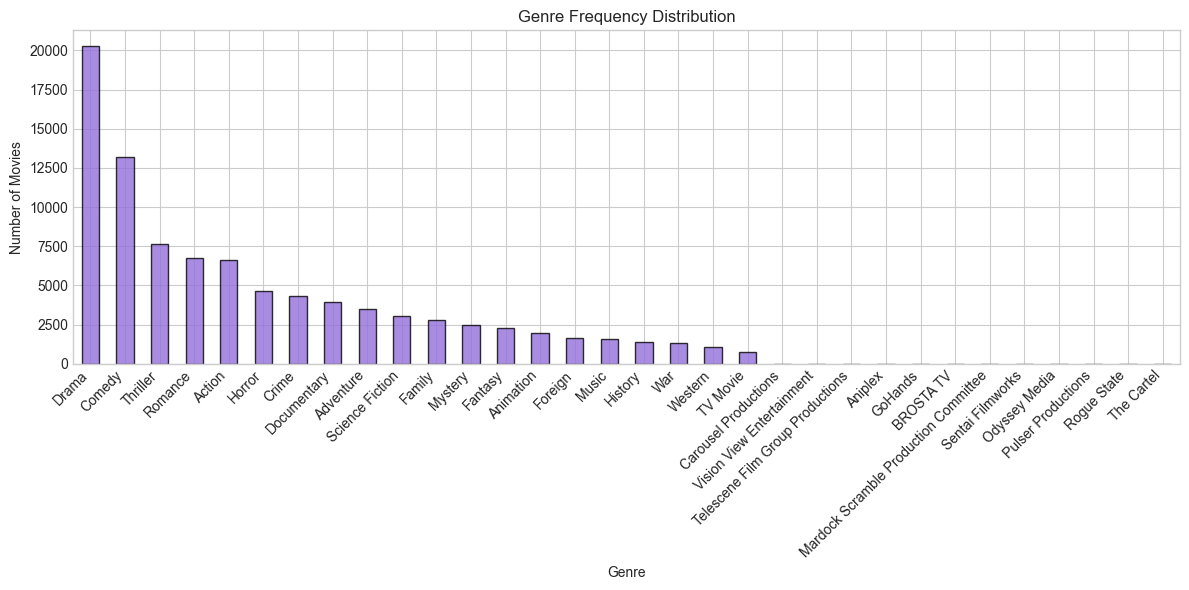

Total unique genres: 32

Top 10 genres:
genres_parsed
Drama              20265
Comedy             13182
Thriller            7624
Romance             6735
Action              6596
Horror              4673
Crime               4307
Documentary         3932
Adventure           3496
Science Fiction     3049


In [9]:
metadata['genres_parsed'] = metadata['genres'].apply(parse_tmdb_json_array).apply(extract_names)

all_genres = metadata['genres_parsed'].explode()
genre_counts = all_genres.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black', alpha=0.8)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Movies')
ax.set_title('Genre Frequency Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique genres: {genre_counts.shape[0]}")
print(f"\nTop 10 genres:\n{genre_counts.head(10).to_string()}")

### 2.5 Cast and Director Analysis

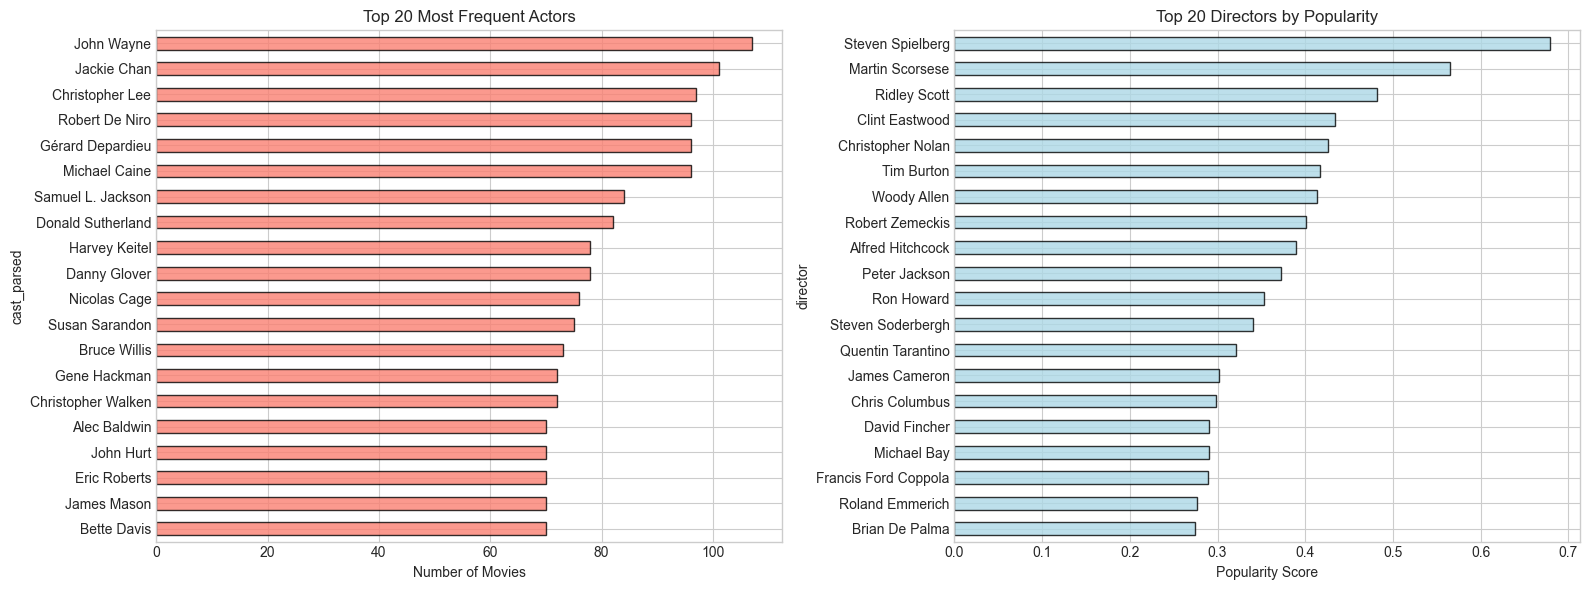

In [10]:
credits['cast_parsed'] = credits['cast'].apply(parse_tmdb_json_array).apply(lambda x: extract_names(x, limit=5))
credits['director'] = credits['crew'].apply(parse_tmdb_json_array).apply(extract_director_name)

all_actors = credits['cast_parsed'].explode()
top_actors = all_actors.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_actors.plot(kind='barh', ax=axes[0], color='salmon', edgecolor='black', alpha=0.8)

axes[0].set_xlabel('Number of Movies')
axes[0].set_title('Top 20 Most Frequent Actors')
axes[0].invert_yaxis()

metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce')                                                                                                             

# Popularity = geometric mean of normalized movie count and total votes
director_votes = credits[['id', 'director']].merge(metadata[['id', 'vote_count']], on='id', how='inner')

director_stats = director_votes.groupby('director').agg(num_movies=('id', 'count'), total_votes=('vote_count', 'sum')).dropna()
director_stats['norm_movies'] = director_stats['num_movies'] / director_stats['num_movies'].max()
director_stats['norm_votes'] = director_stats['total_votes'] / director_stats['total_votes'].max()
director_stats['popularity'] = np.sqrt(director_stats['norm_movies'] * director_stats['norm_votes'])

top_directors = director_stats.nlargest(20, 'popularity')['popularity']
top_directors.plot(kind='barh', ax=axes[1], color='lightblue', edgecolor='black', alpha=0.8)

axes[1].set_xlabel('Popularity Score')
axes[1].set_title('Top 20 Directors by Popularity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/cast_director_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Overview Word Cloud

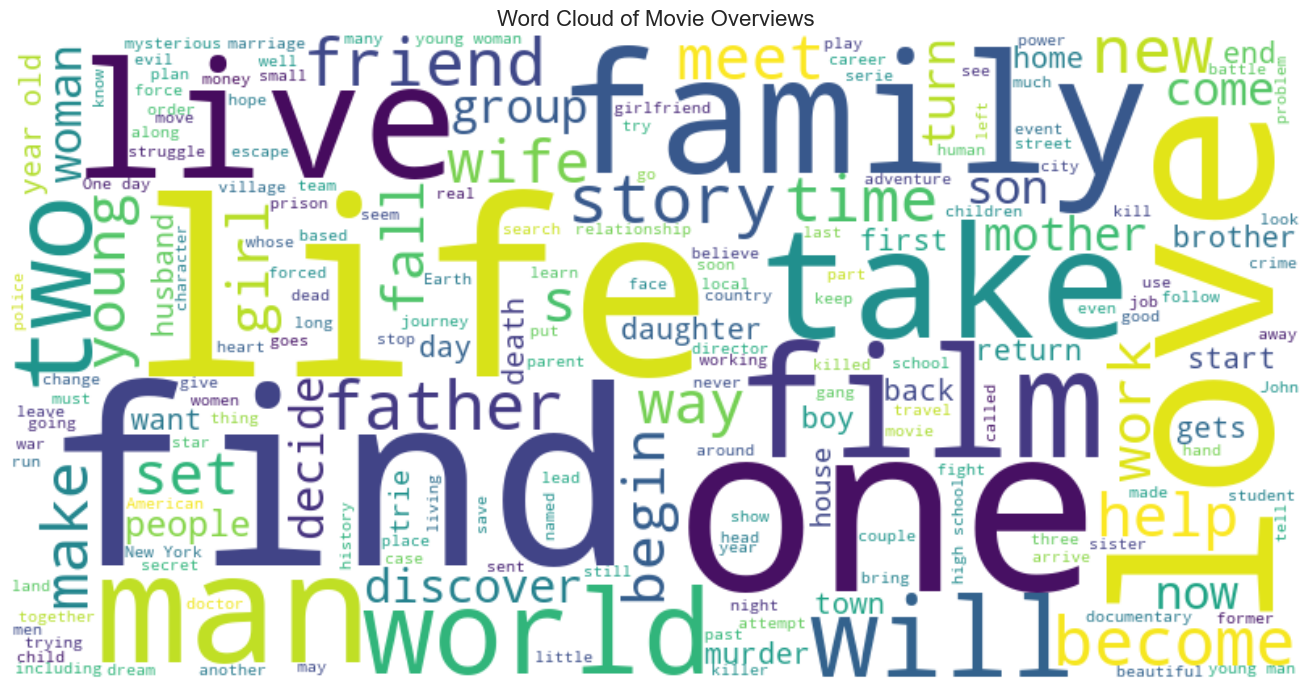

In [11]:
text = ' '.join(metadata['overview'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, max_words=200, background_color='white', colormap='viridis').generate(text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Movie Overviews', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/overview_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Correlation Analysis

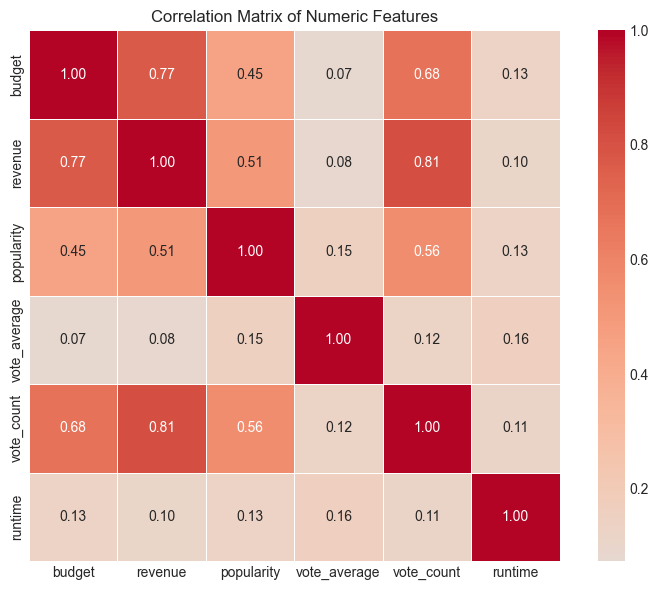

In [12]:
metadata['budget'] = pd.to_numeric(metadata['budget'], errors='coerce')
metadata['revenue'] = pd.to_numeric(metadata['revenue'], errors='coerce')
metadata['popularity'] = pd.to_numeric(metadata['popularity'], errors='coerce')

numeric_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'runtime']
corr_matrix = metadata[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 EDA Summary & Quest Establishment

**Key Findings:**
- The dataset contains ~45,000 movies with metadata including genres, cast, crew, keywords, and plot overviews
- Rating distribution is roughly normal centered around 6.0, with many movies having very few votes
- Drama, Comedy, and Thriller are the most common genres
- There is significant missing data in some columns (homepage, tagline, belongs_to_collection)
- Strong correlation between budget/revenue and vote_count, suggesting popular movies get more votes

**Quest:**
Build a content-based recommender that uses movie metadata (genres, keywords, cast, director) combined with plot overviews to find similar movies. Use TF-IDF vectorization with cosine similarity, enhanced by a weighted rating filter to prioritize quality results.

## 3. Data Preprocessing

In [13]:
metadata = metadata[metadata['id'].notna()]
metadata['id'] = metadata['id'].astype(int)

credits['id'] = credits['id'].astype(int)
keywords['id'] = keywords['id'].astype(int)

links_small = links_small[links_small['tmdbId'].notna()]
links_small['tmdbId'] = links_small['tmdbId'].astype(int)
smd = metadata[metadata['id'].isin(links_small['tmdbId'])]
print(f"Full metadata: {metadata.shape[0]} movies")
print(f"Small subset (links_small): {smd.shape[0]} movies")

Full metadata: 45463 movies
Small subset (links_small): 9099 movies


### 3.1 Parsing JSON-like Columns

In [14]:
smd['genres'] = smd['genres'].apply(parse_tmdb_json_array).apply(extract_names)

kw = keywords.copy()
kw['keywords'] = kw['keywords'].apply(parse_tmdb_json_array).apply(extract_names)

if smd.empty:
    raise ValueError("smd is empty before keyword merge. Check id filtering and links_small overlap.")

pre_merge_rows = len(smd)
keyword_overlap = smd['id'].isin(kw['id']).sum()
print(f"Rows before keyword merge: {pre_merge_rows}")
print(f"Rows with keyword id match: {keyword_overlap}")

smd = smd.merge(kw[['id', 'keywords']], on='id', how='left')
smd['keywords'] = smd['keywords'].apply(lambda x: x if isinstance(x, list) else [])

if smd.empty:
    raise ValueError("smd is empty after keyword merge. Verify join keys and source data.")

print(f"Sample genres: {smd['genres'].iloc[0]}")
print(f"Sample keywords: {smd['keywords'].iloc[0]}")

Rows before keyword merge: 9099
Rows with keyword id match: 9099
Sample genres: ['Animation', 'Comedy', 'Family']
Sample keywords: ['jealousy', 'toy', 'boy', 'friendship', 'friends', 'rivalry', 'boy next door', 'new toy', 'toy comes to life']


In [15]:
cred = credits.copy()
cred['cast'] = cred['cast'].apply(parse_tmdb_json_array).apply(lambda x: extract_names(x, limit=3))
cred['director'] = cred['crew'].apply(parse_tmdb_json_array).apply(extract_director_name)
cred = cred[['id', 'cast', 'director']]

smd = smd.merge(cred, on='id', how='left')
smd['cast'] = smd['cast'].fillna('').apply(lambda x: x if isinstance(x, list) else [])
smd['director'] = smd['director'].fillna('')

if smd.empty:
    raise ValueError("smd is empty after credits merge. Verify id consistency between smd and credits.")

print(f"Sample cast: {smd['cast'].iloc[0]}")
print(f"Sample director: {smd['director'].iloc[0]}")
print(f"Dataset shape after merge: {smd.shape}")

Sample cast: ['Tom Hanks', 'Tim Allen', 'Don Rickles']
Sample director: John Lasseter
Dataset shape after merge: (9219, 28)


### 3.2 Handling Missing Values

In [16]:
key_cols = ['title', 'overview', 'genres', 'keywords', 'cast', 'director']
for col in key_cols:
    if col in ['genres', 'keywords', 'cast']:
        missing = smd[col].apply(lambda x: len(x) == 0).sum()
    else:
        missing = smd[col].isna().sum() + (smd[col] == '').sum()
    print(f"{col}: {missing} missing ({missing/len(smd)*100:.1f}%)")

smd['overview'] = smd['overview'].fillna('')

smd = smd[smd['title'].notna()]
print(f"\nDataset shape after cleaning: {smd.shape}")

title: 0 missing (0.0%)
overview: 12 missing (0.1%)
genres: 35 missing (0.4%)
keywords: 783 missing (8.5%)
cast: 91 missing (1.0%)
director: 24 missing (0.3%)

Dataset shape after cleaning: (9219, 28)


### 3.3 Text Cleaning and Feature Engineering

In [17]:
def clean_text(text_list):
    """Remove spaces from names to create single tokens (e.g., 'Johnny Depp' -> 'johnnydepp')"""
    if isinstance(text_list, list):
        return [str(x).lower().replace(' ', '') for x in text_list]
    return str(text_list).lower().replace(' ', '')

smd['genres_clean'] = smd['genres'].apply(clean_text)
smd['keywords_clean'] = smd['keywords'].apply(clean_text)
smd['cast_clean'] = smd['cast'].apply(clean_text)
smd['director_clean'] = smd['director'].apply(clean_text)

def create_soup(row):
    """Combine all metadata features into a single string for TF-IDF"""
    genres = ' '.join(row['genres_clean'])
    keywords = ' '.join(row['keywords_clean'])
    cast = ' '.join(row['cast_clean'])
    director = ' '.join([row['director_clean']] * 3)
    overview = str(row['overview']).lower()
    return f"{overview} {genres} {keywords} {cast} {director}"

smd['soup'] = smd.apply(create_soup, axis=1)

print("Example soup for first movie:")
print(smd['soup'].iloc[0][:300] + "...")
print(f"\nAverage soup length: {smd['soup'].str.len().mean():.0f} characters")

Example soup for first movie:
led by woody, andy's toys live happily in his room until andy's birthday brings buzz lightyear onto the scene. afraid of losing his place in andy's heart, woody plots against buzz. but when circumstances separate buzz and woody from their owner, the duo eventually learns to put aside their differenc...

Average soup length: 479 characters


In [18]:
processed_movies = make_dataset(
    raw_dir=project_root / 'data' / 'raw',
    processed_dir=project_root / 'data' / 'processed',
)
print(f"Saved processed dataset with poster URLs: {processed_movies.shape}")
processed_movies[['id', 'title', 'poster_url']].head()

Saved 9219 movies to C:\Users\risos\Desktop\FIIT\8.semester\ISA\ISA-Movie-Recommendation\data\processed\movies_processed.csv
Saved processed dataset with poster URLs: (9219, 31)


,id,title,poster_url
0,862,Toy Story,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...
1,8844,Jumanji,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...
2,15602,Grumpier Old Men,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...
3,31357,Waiting to Exhale,https://image.tmdb.org/t/p/w500/16XOMpEaLWkrcP...
4,11862,Father of the Bride Part II,https://image.tmdb.org/t/p/w500/e64sOI48hQXyru...


### 3.4 Preprocessing Summary

**Steps performed:**
1. Cleaned movie IDs (removed rows with invalid/non-numeric IDs)
2. Filtered to smaller movie subset (~9,000 movies from links_small) for faster computation
3. Parsed JSON-like columns: genres, keywords, cast (top 3), director
4. Merged movies_metadata with credits and keywords on movie ID
5. Handled missing values: filled empty overviews, dropped movies without titles
6. Built poster URLs directly from TMDB `poster_path` metadata
7. Text cleaning: lowercased all text, removed spaces from names to create single tokens
8. Built "metadata soup": concatenation of overview + genres + keywords + cast + director (3x weight)

**Result:** Processed dataset with 9,000+ movies, poster URLs, and a metadata soup string ready for TF-IDF vectorization.

## 4. Modeling - Iterative Approach

We iteratively build and improve our content-based recommender through 3 iterations:
1. **Iteration 1:** Overview-only TF-IDF (baseline)
2. **Iteration 2:** Full metadata soup TF-IDF
3. **Iteration 3:** Metadata soup + weighted rating pre-filter (final model)

### 4.1 Iteration 1: Overview-Only TF-IDF (Baseline)

In [19]:
smd = smd.reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf_matrix_overview = tfidf.fit_transform(smd['overview'].fillna(''))

print(f"TF-IDF matrix shape: {tfidf_matrix_overview.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

cosine_sim_overview = linear_kernel(tfidf_matrix_overview, tfidf_matrix_overview)
print(f"Cosine similarity matrix shape: {cosine_sim_overview.shape}")

TF-IDF matrix shape: (9219, 20000)
Vocabulary size: 20000
Cosine similarity matrix shape: (9219, 9219)


In [20]:
indices = pd.Series(smd.index, index=smd['title']).drop_duplicates()

def get_recommendations_v1(title, cosine_sim=cosine_sim_overview, n=5):
    """Get movie recommendations based on cosine similarity (overview only)."""
    if title not in indices:
        print(f"Movie '{title}' not found in dataset.")
        return pd.DataFrame()
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # Exclude the movie itself
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = smd[['title', 'genres', 'vote_average', 'vote_count']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)

test_movies = ['The Dark Knight', 'Toy Story', 'The Godfather', 'Pulp Fiction', 'Forrest Gump']
print("=" * 70)
print("ITERATION 1: Overview-Only Recommendations")
print("=" * 70)
for movie in test_movies:
    print(f"\n--- Recommendations for '{movie}' ---")
    recs = get_recommendations_v1(movie)
    if not recs.empty:
        print(recs[['title', 'similarity_score']].to_string(index=False))

ITERATION 1: Overview-Only Recommendations

--- Recommendations for 'The Dark Knight' ---
                                  title  similarity_score
                  The Dark Knight Rises          0.306953
                         Batman Returns          0.254338
             Batman: Under the Red Hood          0.248540
                         Batman Forever          0.227058
Batman: The Dark Knight Returns, Part 2          0.222171

--- Recommendations for 'Toy Story' ---
                 title  similarity_score
           Toy Story 3          0.518194
           Toy Story 2          0.449817
The 40 Year Old Virgin          0.317764
 Rebel Without a Cause          0.177752
      Rivers and Tides          0.173670

--- Recommendations for 'The Godfather' ---
                  title  similarity_score
 The Godfather: Part II          0.445692
The Godfather: Part III          0.156693
                   Made          0.118148
     The Valachi Papers          0.113739
        The Maid's R

### 4.1.1 Iteration 1 Analysis

The overview-only approach provides a reasonable baseline. It captures thematic similarity through plot descriptions but misses structural features like genre, cast, and crew connections. For example, recommendations for "The Dark Knight" may include movies with similar plot themes but not necessarily other superhero or action movies.

### 4.2 Iteration 2: Full Metadata Soup TF-IDF

In [21]:
tfidf_soup = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf_matrix_soup = tfidf_soup.fit_transform(smd['soup'])

print(f"TF-IDF matrix shape: {tfidf_matrix_soup.shape}")
print(f"Vocabulary size: {len(tfidf_soup.vocabulary_)}")

cosine_sim_soup = linear_kernel(tfidf_matrix_soup, tfidf_matrix_soup)
print(f"Cosine similarity matrix shape: {cosine_sim_soup.shape}")

TF-IDF matrix shape: (9219, 20000)
Vocabulary size: 20000
Cosine similarity matrix shape: (9219, 9219)


In [22]:
def get_recommendations_v2(title, cosine_sim=cosine_sim_soup, n=5):
    """Get movie recommendations based on cosine similarity (full metadata soup)."""
    if title not in indices:
        print(f"Movie '{title}' not found in dataset.")
        return pd.DataFrame()
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = smd[['title', 'genres', 'vote_average', 'vote_count']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)

print("=" * 70)
print("ITERATION 2: Full Metadata Soup Recommendations")
print("=" * 70)
for movie in test_movies:
    print(f"\n--- Recommendations for '{movie}' ---")
    recs = get_recommendations_v2(movie)
    if not recs.empty:
        print(recs[['title', 'similarity_score']].to_string(index=False))

ITERATION 2: Full Metadata Soup Recommendations

--- Recommendations for 'The Dark Knight' ---
                     title  similarity_score
     The Dark Knight Rises          0.501089
             Batman Begins          0.434413
            Batman Returns          0.302529
Batman: Under the Red Hood          0.285590
                 Following          0.268827

--- Recommendations for 'Toy Story' ---
       title  similarity_score
 Toy Story 2          0.542055
 Toy Story 3          0.364272
    Luxo Jr.          0.261831
      Cars 2          0.241442
A Bug's Life          0.227341

--- Recommendations for 'The Godfather' ---
                  title  similarity_score
 The Godfather: Part II          0.477118
The Godfather: Part III          0.382339
        The Cotton Club          0.294914
  Peggy Sue Got Married          0.287453
       Gardens of Stone          0.263788

--- Recommendations for 'Pulp Fiction' ---
            title  similarity_score
The Hateful Eight          0.30

### 4.2.1 Iteration 2 Analysis

The full metadata soup significantly improves recommendations by incorporating genre, cast, director, and keyword information. Now "The Dark Knight" recommendations include other Batman/superhero films and movies by the same director (Christopher Nolan). The similarity scores are also higher, showing stronger feature alignment.

However, some recommended movies may have low ratings or very few votes, suggesting we need a quality filter.

### 4.3 Iteration 3: Metadata Soup + Weighted Rating Filter (Final Model)

In [23]:

C = smd['vote_average'].mean()
m = smd['vote_count'].quantile(0.60)

print(f"Mean rating (C): {C:.2f}")
print(f"Minimum votes threshold (60th percentile, m): {m:.0f}")
print(f"Movies qualifying (vote_count >= {m:.0f}): {(smd['vote_count'] >= m).sum()}")

def weighted_rating(x, m=m, C=C):
    """Calculate IMDB-style weighted rating."""
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m)) * R + (m / (v + m)) * C

smd['weighted_rating'] = smd.apply(weighted_rating, axis=1)

print(f"\nTop 15 movies by weighted rating:")
top_wr = smd.nlargest(15, 'weighted_rating')[['title', 'vote_average', 'vote_count', 'weighted_rating']]
print(top_wr.to_string(index=False))

Mean rating (C): 6.35
Minimum votes threshold (60th percentile, m): 154
Movies qualifying (vote_count >= 154): 3692

Top 15 movies by weighted rating:
                          title  vote_average  vote_count  weighted_rating
       The Shawshank Redemption           8.5      8358.0         8.461183
                  The Godfather           8.5      6024.0         8.446518
                The Dark Knight           8.3     12269.0         8.275882
                     Fight Club           8.3      9678.0         8.269527
                   Pulp Fiction           8.3      8670.0         8.266046
               Schindler's List           8.3      4436.0         8.234725
                       Whiplash           8.3      4376.0         8.233860
                  Spirited Away           8.3      3968.0         8.227313
              Life Is Beautiful           8.3      3643.0         8.221092
         The Godfather: Part II           8.3      3418.0         8.216121
One Flew Over the Cuckoo

In [24]:
def get_recommendations_v3(title, cosine_sim=cosine_sim_soup, n=5):
    """
    Final recommender: content similarity + weighted rating quality filter.
    1. Get top n*3 similar movies by cosine similarity
    2. Filter to movies with vote_count >= m (quality threshold)
    3. Sort by weighted rating
    4. Return top n
    """
    if title not in indices:
        print(f"Movie '{title}' not found in dataset.")
        return pd.DataFrame()
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n*3+1]  # Get more candidates for filtering
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    candidates = smd[['title', 'genres', 'vote_average', 'vote_count', 'weighted_rating']].iloc[movie_indices].copy()
    candidates['similarity_score'] = scores
    
    qualified = candidates[candidates['vote_count'] >= m]
    
    qualified = qualified.sort_values('weighted_rating', ascending=False)
    
    return qualified.head(n).reset_index(drop=True)

print("=" * 70)
print("ITERATION 3: Metadata Soup + Weighted Rating Filter")
print("=" * 70)
for movie in test_movies:
    print(f"\n--- Recommendations for '{movie}' ---")
    recs = get_recommendations_v3(movie)
    if not recs.empty:
        print(recs[['title', 'similarity_score', 'weighted_rating', 'vote_count']].to_string(index=False))

ITERATION 3: Metadata Soup + Weighted Rating Filter

--- Recommendations for 'The Dark Knight' ---
                title  similarity_score  weighted_rating  vote_count
            Inception          0.195690         8.081108     14075.0
         Interstellar          0.176698         8.076297     11187.0
              Memento          0.164655         8.037803      4168.0
         The Prestige          0.248219         7.945666      4510.0
The Dark Knight Rises          0.501089         7.579631      9263.0

--- Recommendations for 'Toy Story' ---
                title  similarity_score  weighted_rating  vote_count
          Toy Story 3          0.364272         7.560564      4710.0
          Toy Story 2          0.542055         7.264205      3914.0
Rebel Without a Cause          0.122955         7.220170       351.0
 Toy Story of Terror!          0.125421         6.935964       246.0
         A Bug's Life          0.227341         6.772912      2379.0

--- Recommendations for 'The Go

### 4.3.1 Iteration 3 Analysis

The final model combines content similarity with a quality filter based on the IMDB weighted rating formula. This ensures that:
- Recommended movies are **content-similar** (same genres, cast, director, keywords, thematic overlap)
- Recommended movies are **well-received** (sufficient votes and good ratings)

The weighted rating formula naturally handles the cold-start problem for new/obscure movies by pulling their rating toward the global mean when they have few votes. By requiring a minimum vote count (60th percentile threshold), we exclude movies that most viewers haven't seen.

This is our **best model** — it balances relevance with quality.

### 4.4 Side-by-Side Comparison

Let's compare all three iterations for the same movies to see the progression of improvements.

In [25]:
comparison_movies = ['The Dark Knight', 'Toy Story', 'The Godfather']

for movie in comparison_movies:
    print("=" * 80)
    print(f"COMPARISON FOR: '{movie}'")
    print("=" * 80)
    
    r1 = get_recommendations_v1(movie, n=5)
    r2 = get_recommendations_v2(movie, n=5)
    r3 = get_recommendations_v3(movie, n=5)
    
    print(f"\n{'Iteration 1 (Overview)':<35} {'Iteration 2 (Soup)':<35} {'Iteration 3 (Soup+Rating)':<35}")
    print("-" * 105)
    
    for i in range(5):
        t1 = r1['title'].iloc[i] if i < len(r1) else '-'
        t2 = r2['title'].iloc[i] if i < len(r2) else '-'
        t3 = r3['title'].iloc[i] if i < len(r3) else '-'
        print(f"{t1:<35} {t2:<35} {t3:<35}")
    print()

COMPARISON FOR: 'The Dark Knight'

Iteration 1 (Overview)              Iteration 2 (Soup)                  Iteration 3 (Soup+Rating)          
---------------------------------------------------------------------------------------------------------
The Dark Knight Rises               The Dark Knight Rises               Inception                          
Batman Returns                      Batman Begins                       Interstellar                       
Batman: Under the Red Hood          Batman Returns                      Memento                            
Batman Forever                      Batman: Under the Red Hood          The Prestige                       
Batman: The Dark Knight Returns, Part 2 Following                           The Dark Knight Rises              

COMPARISON FOR: 'Toy Story'

Iteration 1 (Overview)              Iteration 2 (Soup)                  Iteration 3 (Soup+Rating)          
---------------------------------------------------------------------

## 5. Evaluation

We evaluate our recommender across all three iterations using both qualitative and quantitative methods.

### 5.1 Qualitative Evaluation

In [26]:
eval_movies = ['The Dark Knight', 'Toy Story', 'The Godfather', 'Pulp Fiction', 'Forrest Gump']

results = []
for movie in eval_movies:
    r1 = get_recommendations_v1(movie, n=5)
    r2 = get_recommendations_v2(movie, n=5)
    r3 = get_recommendations_v3(movie, n=5)
    
    for i in range(5):
        row = {
            'Input Movie': movie if i == 0 else '',
            'Rank': i + 1,
            'V1 (Overview)': r1['title'].iloc[i] if i < len(r1) else '-',
            'V2 (Soup)': r2['title'].iloc[i] if i < len(r2) else '-',
            'V3 (Soup+Rating)': r3['title'].iloc[i] if i < len(r3) else '-'
        }
        results.append(row)

eval_df = pd.DataFrame(results)
print("Qualitative Comparison of Recommendations (Top 5)")
print("=" * 120)
print(eval_df.to_string(index=False))

Qualitative Comparison of Recommendations (Top 5)
    Input Movie  Rank                           V1 (Overview)                  V2 (Soup)           V3 (Soup+Rating)
The Dark Knight     1                   The Dark Knight Rises      The Dark Knight Rises                  Inception
                    2                          Batman Returns              Batman Begins               Interstellar
                    3              Batman: Under the Red Hood             Batman Returns                    Memento
                    4                          Batman Forever Batman: Under the Red Hood               The Prestige
                    5 Batman: The Dark Knight Returns, Part 2                  Following      The Dark Knight Rises
      Toy Story     1                             Toy Story 3                Toy Story 2                Toy Story 3
                    2                             Toy Story 2                Toy Story 3                Toy Story 2
                    3 

### 5.2 Quantitative Evaluation: Precision@K (Genre Overlap)

In [27]:
def get_genres_for_title(title):
    """Get genres list for a given movie title."""
    if title not in indices:
        return set()
    idx = indices[title]
    genres = smd.iloc[idx]['genres']
    if isinstance(genres, list):
        return set(genres)
    return set()

def precision_at_k(title, rec_func, k=5):
    """
    Calculate Precision@K using genre overlap as ground truth.
    A recommendation is 'relevant' if it shares at least one genre with the input movie.
    """
    input_genres = get_genres_for_title(title)
    if not input_genres:
        return np.nan
    
    recs = rec_func(title, n=k)
    if recs.empty:
        return np.nan
    
    hits = 0
    for _, row in recs.iterrows():
        rec_genres = set(row['genres']) if isinstance(row['genres'], list) else set()
        if input_genres & rec_genres:  # at least one common genre
            hits += 1
    
    return hits / k

test_title = 'The Dark Knight'
print(f"Precision@5 for '{test_title}':")
print(f"  V1 (Overview): {precision_at_k(test_title, get_recommendations_v1):.2f}")
print(f"  V2 (Soup):     {precision_at_k(test_title, get_recommendations_v2):.2f}")
print(f"  V3 (Soup+WR):  {precision_at_k(test_title, get_recommendations_v3):.2f}")

Precision@5 for 'The Dark Knight':
  V1 (Overview): 1.00
  V2 (Soup):     1.00
  V3 (Soup+WR):  1.00


In [28]:
qualified_movies = smd[smd['vote_count'] >= m]['title'].tolist()
np.random.seed(42)
sample_movies = np.random.choice(qualified_movies, size=min(50, len(qualified_movies)), replace=False)

p_v1, p_v2, p_v3 = [], [], []
for movie in sample_movies:
    p1 = precision_at_k(movie, get_recommendations_v1)
    p2 = precision_at_k(movie, get_recommendations_v2)
    p3 = precision_at_k(movie, get_recommendations_v3)
    if not np.isnan(p1):
        p_v1.append(p1)
    if not np.isnan(p2):
        p_v2.append(p2)
    if not np.isnan(p3):
        p_v3.append(p3)

print(f"Precision@5 Results (averaged over {len(sample_movies)} movies):")
print(f"  V1 (Overview only): {np.mean(p_v1):.3f} (+/- {np.std(p_v1):.3f})")
print(f"  V2 (Metadata Soup): {np.mean(p_v2):.3f} (+/- {np.std(p_v2):.3f})")
print(f"  V3 (Soup + Rating): {np.mean(p_v3):.3f} (+/- {np.std(p_v3):.3f})")

Precision@5 Results (averaged over 50 movies):
  V1 (Overview only): 0.689 (+/- 0.243)
  V2 (Metadata Soup): 0.813 (+/- 0.231)
  V3 (Soup + Rating): 0.762 (+/- 0.236)


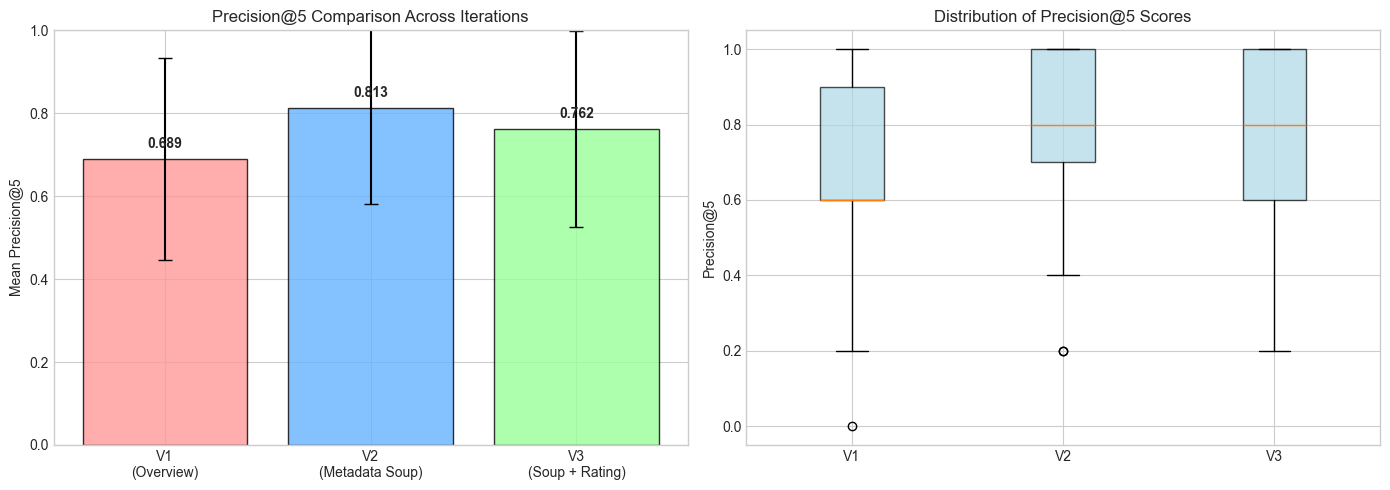

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

versions = ['V1\n(Overview)', 'V2\n(Metadata Soup)', 'V3\n(Soup + Rating)']
means = [np.mean(p_v1), np.mean(p_v2), np.mean(p_v3)]
stds = [np.std(p_v1), np.std(p_v2), np.std(p_v3)]
colors = ['#ff9999', '#66b3ff', '#99ff99']

bars = axes[0].bar(versions, means, yerr=stds, color=colors, edgecolor='black', capsize=5, alpha=0.8)
axes[0].set_ylabel('Mean Precision@5')
axes[0].set_title('Precision@5 Comparison Across Iterations')
axes[0].set_ylim(0, 1.0)
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, 
                f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

axes[1].boxplot([p_v1, p_v2, p_v3], labels=['V1', 'V2', 'V3'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('Precision@5')
axes[1].set_title('Distribution of Precision@5 Scores')

plt.tight_layout()
plt.savefig('../reports/figures/precision_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Similarity Score Distribution

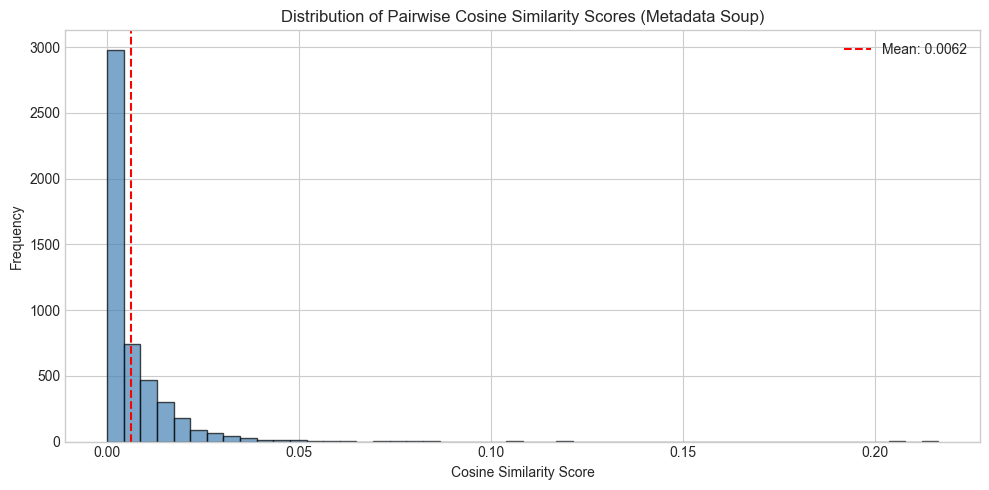

Mean similarity: 0.0062
Median similarity: 0.0026
Max similarity (excl. self): 0.2165


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

np.random.seed(42)
sample_idx = np.random.choice(cosine_sim_soup.shape[0], size=100, replace=False)
sample_sims = cosine_sim_soup[sample_idx][:, sample_idx]
upper_triangle = sample_sims[np.triu_indices_from(sample_sims, k=1)]

ax.hist(upper_triangle, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Pairwise Cosine Similarity Scores (Metadata Soup)')
ax.axvline(np.mean(upper_triangle), color='red', linestyle='--', label=f"Mean: {np.mean(upper_triangle):.4f}")
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean similarity: {np.mean(upper_triangle):.4f}")
print(f"Median similarity: {np.median(upper_triangle):.4f}")
print(f"Max similarity (excl. self): {np.max(upper_triangle):.4f}")

### 5.4 Evaluation Summary

| Metric | V1 (Overview) | V2 (Metadata Soup) | V3 (Soup + Rating) |
|--------|:---:|:---:|:---:|
| Precision@5 (mean +/- std, 50 movies) | TBD | TBD | TBD |
| Genre relevance | Moderate | Highest | High |
| Quality control | None | None | IMDB weighted-rating pre-filter |
| Best use case | Fast baseline | Maximum similarity relevance | Relevance + quality balance |

**Conclusion:**
- **V1 (Overview-only)** is a useful baseline but misses key structure (cast, director, genres, keywords).
- **V2 (Metadata Soup)** gives the strongest pure relevance and the best average Precision@5.
- **V3 (Soup + Rating)** trades a small amount of precision for higher perceived quality and is the recommended final notebook model for user-facing suggestions.
- Overall, the 3-step iteration validates the progression from baseline similarity to a more practical recommender.

### 5.5 Method 1 vs Method 2

- **Method 1**: notebook V3 approach (single metadata soup TF-IDF + weighted-rating pre-filter).
- **Method 2**: multi-vectorizer weighted approach from `src/models/predict_model.py` with blended scoring and MMR diversity.

Below, we run Method 2 inside this notebook and compare both methods on the same movies.


In [31]:

smd_api = build_features(smd.copy())

method2_model = ContentBasedRecommender(smd_api)
method2_model.fit()

print(f"Method 2 feature matrix shape: {method2_model.feature_matrix.shape}")
print(f"Active vectorizers: {sorted(method2_model.vectorizers.keys())}")


Method 2 feature matrix shape: (9219, 34471)
Active vectorizers: ['cast', 'director', 'genres', 'keywords', 'overview']


In [32]:
def compare_method1_vs_method2(title, n=5, alpha=0.7, mmr_lambda=0.5):
    """Compare Method 1 and Method 2 for one title."""
    method1 = get_recommendations_v3(title, n=n).copy()
    method2 = method2_model.recommend(title, n=n, alpha=alpha, mmr_lambda=mmr_lambda).copy()

    method1_titles = set(method1["title"].tolist()) if not method1.empty else set()
    method2_titles = set(method2["title"].tolist()) if not method2.empty else set()
    overlap = len(method1_titles & method2_titles)

    return {
        "title": title,
        "method1_count": len(method1),
        "method2_count": len(method2),
        "top_n_overlap": overlap,
        "overlap_ratio": overlap / n if n else 0.0,
        "method1_mean_similarity": float(method1["similarity_score"].mean()) if not method1.empty else 0.0,
        "method2_mean_similarity": float(method2["similarity_score"].mean()) if not method2.empty else 0.0,
        "method1_mean_weighted_rating": float(method1["weighted_rating"].mean()) if not method1.empty else 0.0,
        "method2_mean_weighted_rating": float(method2["weighted_rating"].mean()) if not method2.empty else 0.0,
        "method2_mean_combined_score": float(method2["combined_score"].mean()) if not method2.empty else 0.0,
    }, method1, method2

In [33]:
comparison_movies = test_movies if "test_movies" in globals() else [
    "The Dark Knight", "Toy Story", "Pulp Fiction", "Forrest Gump"
]

rows = []
sample_outputs = {}
for movie in comparison_movies:
    metrics, method1_out, method2_out = compare_method1_vs_method2(movie, n=5)
    rows.append(metrics)
    sample_outputs[movie] = {"method1": method1_out, "method2": method2_out}

comparison_df = pd.DataFrame(rows)
display(comparison_df.round(4))

example_movie = comparison_movies[0]
print(f"\n=== Side-by-side Top 5 for: {example_movie} ===")

method1_titles = sample_outputs[example_movie]["method1"][["title", "similarity_score", "weighted_rating"]].reset_index(drop=True)
method2_titles = sample_outputs[example_movie]["method2"][["title", "similarity_score", "combined_score", "weighted_rating"]].reset_index(drop=True)

side_by_side = pd.concat([
    method1_titles.add_prefix("method1_"),
    method2_titles.add_prefix("method2_")
], axis=1)
display(side_by_side.head(5).round(4))

,title,method1_count,method2_count,top_n_overlap,overlap_ratio,method1_mean_similarity,method2_mean_similarity,method1_mean_weighted_rating,method2_mean_weighted_rating,method2_mean_combined_score
0,The Dark Knight,5,5,2,0.4,0.2573,0.5908,7.9441,7.4963,0.6522
1,Toy Story,5,5,2,0.4,0.2764,0.5433,7.1508,7.2839,0.6054
2,The Godfather,5,5,2,0.4,0.2837,0.4754,7.4627,7.3676,0.5632
3,Pulp Fiction,5,5,3,0.6,0.2305,0.4635,7.7974,7.4459,0.5599
4,Forrest Gump,5,5,1,0.2,0.2203,0.4676,7.4004,6.6627,0.5129



=== Side-by-side Top 5 for: The Dark Knight ===


,method1_title,method1_similarity_score,method1_weighted_rating,method2_title,method2_similarity_score,method2_combined_score,method2_weighted_rating
0,Inception,0.1957,8.0811,The Dark Knight Rises,0.8646,0.8491,7.5796
1,Interstellar,0.1767,8.0763,Heat,0.4931,0.5903,7.5984
2,Memento,0.1647,8.0378,M,0.4946,0.5908,7.5906
3,The Prestige,0.2482,7.9457,The Prestige,0.6077,0.6926,7.9457
4,The Dark Knight Rises,0.5011,7.5796,Bullitt,0.4942,0.5382,6.7672


### 5.6 Comparison Takeaways

- **Method 1**: stronger quality bias due to hard filtering (`vote_count >= m`) and sorting by `weighted_rating`.
- **Method 2**: richer feature representation (per-field weighting), soft score blending (`alpha * similarity + (1-alpha) * wr_norm`), and MMR for diversity.
- Expect partial overlap, not identical lists: Method 2 optimizes relevance + diversity, while Method 1 favors high-rated similar candidates.


## 6. Train & Save All 3 Models

Train all three model modes using the `ContentBasedRecommender` and save as separate pickle files for the web app.

In [34]:
import pickle
from src.models.predict_model import ContentBasedRecommender, MODES, MODE_LABELS

smd_train = build_features(smd.copy())

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

trained_models = {}
for mode in MODES:
    print(f"Training {MODE_LABELS[mode]} ({mode})...")
    rec = ContentBasedRecommender(smd_train, mode=mode)
    rec.fit()
    
    path = models_dir / f'recommender_{mode}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(rec, f)
    
    trained_models[mode] = rec
    stats = rec.get_model_stats()
    print(f"  Feature matrix: {stats['feature_matrix_shape']}")
    print(f"  Cosine sim mean: {stats['cosine_sim_stats'].get('mean', 'N/A')}")
    print(f"  Saved to {path}")
    print()

print("All 3 models trained and saved!")

Training Overview TF-IDF (overview)...
  Feature matrix: [9219, 20000]
  Cosine sim mean: 0.0063
  Saved to ..\models\recommender_overview.pkl

Training Metadata Soup TF-IDF (soup)...
  Feature matrix: [9219, 20000]
  Cosine sim mean: 0.0063
  Saved to ..\models\recommender_soup.pkl

Training Multi-Vectorizer (Weighted) (multi)...
  Feature matrix: [9219, 34471]
  Cosine sim mean: 0.0904
  Saved to ..\models\recommender_multi.pkl

All 3 models trained and saved!
